In [1]:
%pip install pandas numpy matplotlib scikit-learn statsmodels


  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 441.3 kB/s eta 0:00:25
   - --------------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")


In [7]:
import os


path = r"S:\pollusense\dataset"

city_day = pd.read_csv(os.path.join(path, "city_day.csv"))
station_day = pd.read_csv(os.path.join(path, "station_day.csv"))
stations = pd.read_csv(os.path.join(path, "stations.csv"))

print(city_day.head())

        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  


In [8]:
# Filter only Delhi data
delhi_data = city_day[city_day['City'] == 'Delhi'].copy()

# Convert Date column
delhi_data['Date'] = pd.to_datetime(delhi_data['Date'])

# Sort by date
delhi_data = delhi_data.sort_values('Date')

print("Delhi Data Shape:", delhi_data.shape)
delhi_data.head()


Delhi Data Shape: (2009, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
10229,Delhi,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,9.84,472.0,Severe
10230,Delhi,2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,4.29,454.0,Severe
10231,Delhi,2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,1.99,143.0,Moderate
10232,Delhi,2015-01-04,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,9.71,3.34,319.0,Very Poor
10233,Delhi,2015-01-05,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,6.21,2.96,325.0,Very Poor


In [9]:
features = ['PM2.5', 'PM10', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3']
target = 'AQI'

# Keep only needed columns
delhi_data = delhi_data[['Date'] + features + [target]]

# Drop rows where AQI missing
delhi_data = delhi_data.dropna(subset=[target])

# Fill missing feature values with median
for col in features:
    delhi_data[col].fillna(delhi_data[col].median(), inplace=True)

print("After Cleaning:", delhi_data.shape)


After Cleaning: (1999, 10)


In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

X = delhi_data[features]
y = delhi_data[target]

# Time-series split (no shuffle)
X_train, X_test = X[:-100], X[-100:]
y_train, y_test = y[:-100], y[-100:]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("Model MAE:", round(mae,2))
print("Model RMSE:", round(rmse,2))


Model MAE: 19.64
Model RMSE: 23.39


PM2.5 : 80.49 %
PM10 : 9.24 %
NO2 : 1.14 %
NOx : 2.28 %
NH3 : 0.98 %
CO : 2.61 %
SO2 : 0.81 %
O3 : 2.46 %


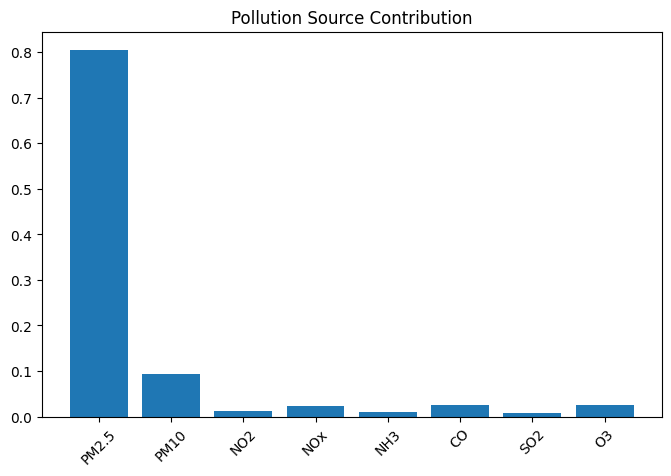

In [11]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

for i, v in enumerate(importance):
    print(features[i], ":", round(v*100,2), "%")

plt.figure(figsize=(8,5))
plt.bar(features, importance)
plt.title("Pollution Source Contribution")
plt.xticks(rotation=45)
plt.show()


In [12]:
from statsmodels.tsa.arima.model import ARIMA

aqi_series = delhi_data['AQI']

# Train ARIMA
model_arima = ARIMA(aqi_series, order=(5,1,0))
model_fit = model_arima.fit()

forecast = model_fit.forecast(steps=3)

print("Next 3 Days AQI Forecast:")
print(forecast)


Next 3 Days AQI Forecast:
1999    117.404526
2000    122.475461
2001    128.579723
Name: predicted_mean, dtype: float64


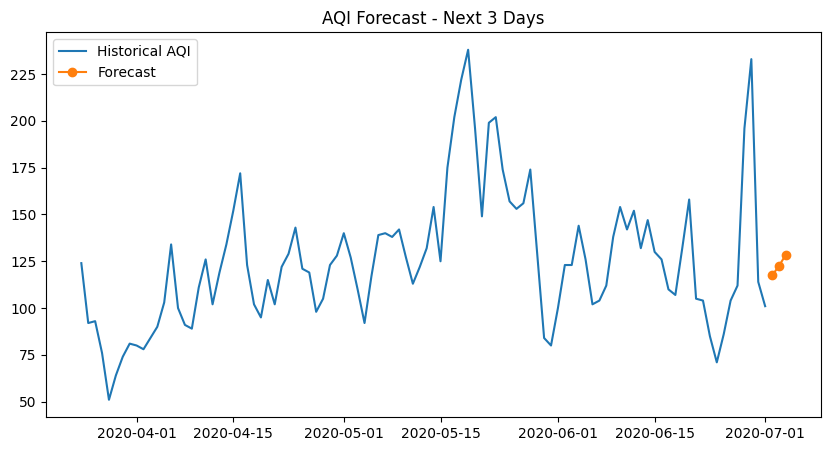

In [13]:
plt.figure(figsize=(10,5))
plt.plot(delhi_data['Date'][-100:], aqi_series[-100:], label='Historical AQI')
future_dates = pd.date_range(delhi_data['Date'].iloc[-1], periods=4, freq='D')[1:]
plt.plot(future_dates, forecast, label='Forecast', marker='o')
plt.legend()
plt.title("AQI Forecast - Next 3 Days")
plt.show()


In [14]:
if max(forecast) > 300:
    print("⚠ Severe AQI Alert Expected in Next 72 Hours")
elif max(forecast) > 200:
    print("⚠ Very Poor AQI Expected")
else:
    print("AQI within moderate range")


AQI within moderate range


In [15]:
def simulate_policy(pm25_reduction=0):
    modified = X_test.copy()
    modified['PM2.5'] = modified['PM2.5'] * (1 - pm25_reduction/100)
    new_pred = model.predict(modified)
    return np.mean(new_pred)

print("Average AQI if PM2.5 reduced by 20%:",
      round(simulate_policy(20),2))


Average AQI if PM2.5 reduced by 20%: 133.24


In [16]:
%pip install shap


  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/547.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/547.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/547.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/547.0 kB ? eta -:--:--
   ------------------------------------ - 524.3/547.0 kB 305.2 kB/s eta 0:00:01
   ---------------------------------------- 547.0/547.0 kB 298.9 kB/s  0:00:01
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
 

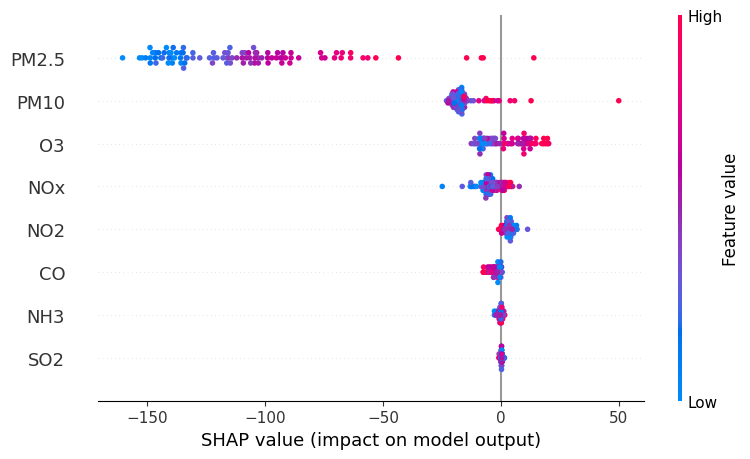

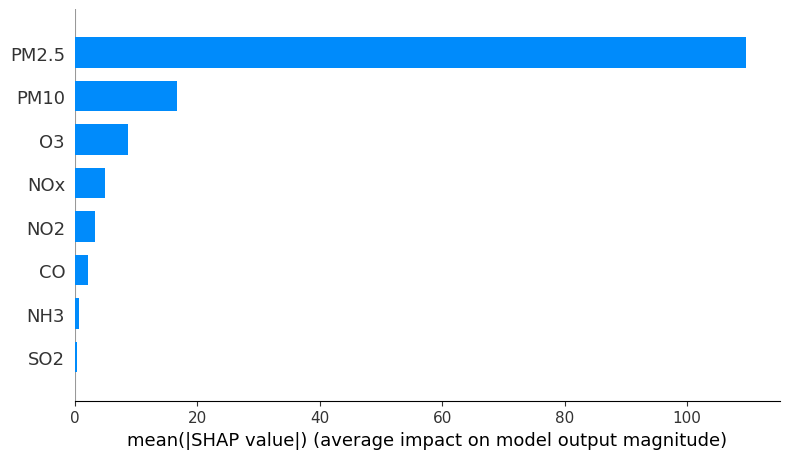

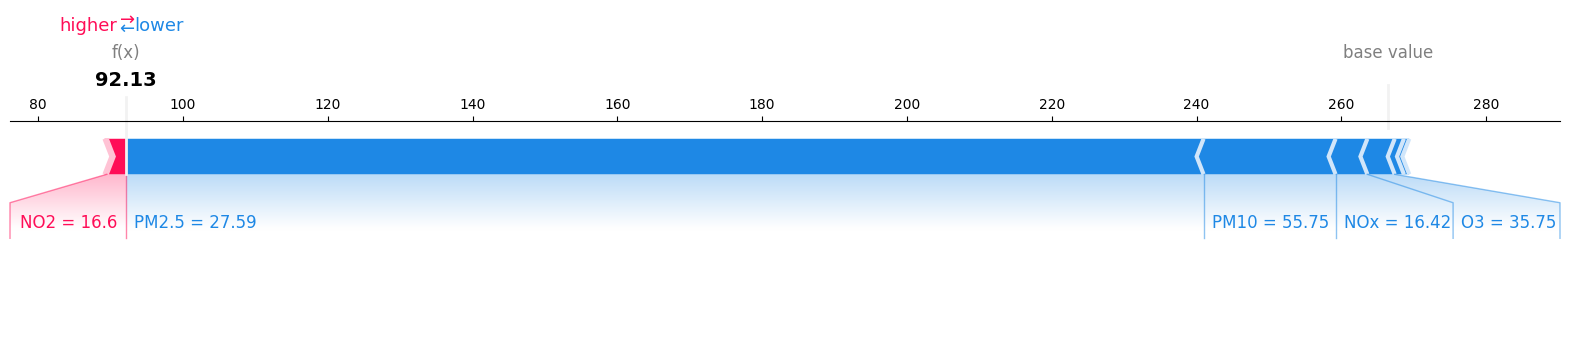

,Feature,SHAP Contribution
2,NO2,2.651508
6,SO2,0.315900
4,NH3,-0.735064
5,CO,-1.274634
7,O3,-3.774792
3,NOx,-4.390372
1,PM10,-18.232399
0,PM2.5,-148.829357


In [17]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")
sample_index = 5

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test.iloc[sample_index],
    matplotlib=True
)
shap_df = pd.DataFrame({
    "Feature": features,
    "SHAP Contribution": shap_values[sample_index]
})

shap_df.sort_values(by="SHAP Contribution", ascending=False)


In [18]:
import numpy as np
import pandas as pd

# Convert shap values to numpy array
shap_array = np.array(shap_values)

# Mean absolute SHAP value for each pollutant
mean_shap = np.abs(shap_array).mean(axis=0)

# Convert to percentage
feature_percentage = (mean_shap / mean_shap.sum()) * 100

# Create DataFrame
feature_contribution = pd.DataFrame({
    "Pollutant": features,
    "Contribution %": feature_percentage
})

feature_contribution


,Pollutant,Contribution %
0,PM2.5,74.854937
1,PM10,11.368792
2,NO2,2.279043
3,NOx,3.329073
4,NH3,0.416523
5,CO,1.511281
6,SO2,0.286474
7,O3,5.953877


In [19]:
# Create mapping dictionary
source_mapping = {
    "Stubble Burning": ["PM2.5", "PM10", "CO"],
    "Traffic": ["NO2", "NOx", "CO"],
    "Industry": ["SO2", "NOx"],
    "Weather": ["O3"]
}

# Calculate source percentage
source_contribution = {}

for source, pollutants in source_mapping.items():
    total = feature_contribution[
        feature_contribution["Pollutant"].isin(pollutants)
    ]["Contribution %"].sum()
    
    source_contribution[source] = total

# Convert to DataFrame
source_df = pd.DataFrame(list(source_contribution.items()),
                         columns=["Source", "Contribution %"])

source_df


,Source,Contribution %
0,Stubble Burning,87.735010
1,Traffic,7.119397
2,Industry,3.615547
3,Weather,5.953877


In [20]:
source_df["Contribution %"] = (
    source_df["Contribution %"] / source_df["Contribution %"].sum()
) * 100

source_df


,Source,Contribution %
0,Stubble Burning,84.018188
1,Traffic,6.817790
2,Industry,3.462377
3,Weather,5.701646


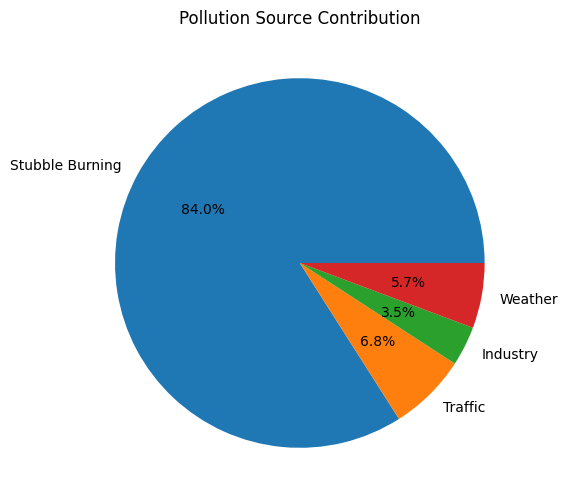

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.pie(source_df["Contribution %"],
        labels=source_df["Source"],
        autopct='%1.1f%%')

plt.title("Pollution Source Contribution")
plt.show()


In [23]:
# Ensure percentages are normalized and rounded properly
source_df["Contribution %"] = (
    source_df["Contribution %"] / source_df["Contribution %"].sum()
) * 100

# Round to whole number
source_df["Contribution %"] = source_df["Contribution %"].round()

# Adjust last value so total = 100
difference = 100 - source_df["Contribution %"].sum()
source_df.loc[source_df.index[-1], "Contribution %"] += difference


# Create explanation dictionary
source_reasons = {}

for index, row in source_df.iterrows():
    
    source = row["Source"]
    percentage = int(row["Contribution %"])  # rounded value
    
    pollutants = source_mapping[source]
    
    # Get SHAP contributions for those pollutants
    contrib = feature_contribution[
        feature_contribution["Pollutant"].isin(pollutants)
    ]
    
    top_pollutants = contrib.sort_values(
        by="Contribution %", ascending=False
    )["Pollutant"].tolist()
    
    if source == "Stubble Burning":
        reason = f"{percentage}% contribution driven by high levels of {', '.join(top_pollutants[:2])}, indicating biomass burning influence."
    
    elif source == "Traffic":
        reason = f"{percentage}% impact linked to elevated {', '.join(top_pollutants[:2])}, suggesting vehicular emissions."
    
    elif source == "Industry":
        reason = f"{percentage}% contribution due to strong presence of {', '.join(top_pollutants[:2])}, reflecting industrial combustion."
    
    elif source == "Weather":
        reason = f"{percentage}% influence attributed to atmospheric chemistry and O3 formation patterns."
    
    source_reasons[source] = reason


# Add reason column
source_df["Reason"] = source_df["Source"].map(source_reasons)

source_df


,Source,Contribution %,Reason
0,Stubble Burning,84.0,84% contribution driven by high levels of PM2....
1,Traffic,7.0,"7% impact linked to elevated NOx, NO2, suggest..."
2,Industry,3.0,"3% contribution due to strong presence of NOx,..."
3,Weather,6.0,6% influence attributed to atmospheric chemist...


In [24]:
# Load hourly dataset
city_hour = pd.read_csv("dataset/city_hour.csv")

city_hour.head()


,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01 01:00:00,NaN,NaN,1.00,40.01,36.37,NaN,1.00,122.07,NaN,0.0,0.0,0.0,NaN,NaN
1,Ahmedabad,2015-01-01 02:00:00,NaN,NaN,0.02,27.75,19.73,NaN,0.02,85.90,NaN,0.0,0.0,0.0,NaN,NaN
2,Ahmedabad,2015-01-01 03:00:00,NaN,NaN,0.08,19.32,11.08,NaN,0.08,52.83,NaN,0.0,0.0,0.0,NaN,NaN
3,Ahmedabad,2015-01-01 04:00:00,NaN,NaN,0.30,16.45,9.20,NaN,0.30,39.53,153.58,0.0,0.0,0.0,NaN,NaN
4,Ahmedabad,2015-01-01 05:00:00,NaN,NaN,0.12,14.90,7.85,NaN,0.12,32.63,NaN,0.0,0.0,0.0,NaN,NaN


In [25]:
# Filter Delhi
delhi_hour = city_hour[city_hour['City'] == 'Delhi'].copy()

# Convert Datetime column
delhi_hour['Datetime'] = pd.to_datetime(delhi_hour['Datetime'])

# Sort properly
delhi_hour = delhi_hour.sort_values('Datetime')

# Drop missing AQI
delhi_hour = delhi_hour.dropna(subset=['AQI'])

print("Shape:", delhi_hour.shape)


Shape: (47694, 16)


In [26]:
aqi_series = delhi_hour['AQI']


In [27]:
from statsmodels.tsa.arima.model import ARIMA

# Train model
model_arima = ARIMA(aqi_series, order=(5,1,0))
model_fit = model_arima.fit()

# Forecast next 72 hours
forecast_72 = model_fit.forecast(steps=72)

print("Next 72 Hour Forecast:")
print(forecast_72.head())


Next 72 Hour Forecast:
47694    101.132807
47695    101.218725
47696    101.274892
47697    101.300340
47698    101.292925
Name: predicted_mean, dtype: float64


In [28]:
last_time = delhi_hour['Datetime'].iloc[-1]

future_times = pd.date_range(
    start=last_time,
    periods=73,
    freq='H'
)[1:]

forecast_df = pd.DataFrame({
    "Datetime": future_times,
    "Predicted AQI": forecast_72
})

forecast_df.head()


,Datetime,Predicted AQI
47694,2020-07-01 01:00:00,101.132807
47695,2020-07-01 02:00:00,101.218725
47696,2020-07-01 03:00:00,101.274892
47697,2020-07-01 04:00:00,101.300340
47698,2020-07-01 05:00:00,101.292925


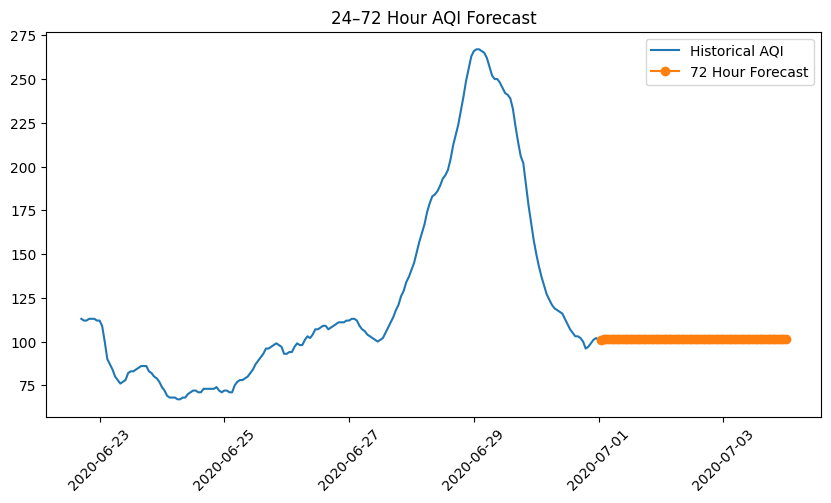

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(delhi_hour['Datetime'][-200:], 
         delhi_hour['AQI'][-200:], 
         label="Historical AQI")

plt.plot(forecast_df["Datetime"],
         forecast_df["Predicted AQI"],
         label="72 Hour Forecast",
         marker='o')

plt.legend()
plt.title("24–72 Hour AQI Forecast")
plt.xticks(rotation=45)
plt.show()


In [30]:
forecast_24 = model_fit.forecast(steps=24)

print("Next 24 Hour Forecast:")
print(forecast_24)


Next 24 Hour Forecast:
47694    101.132807
47695    101.218725
47696    101.274892
47697    101.300340
47698    101.292925
47699    101.303918
47700    101.310639
47701    101.314963
47702    101.317636
47703    101.319133
47704    101.320463
47705    101.321346
47706    101.321944
47707    101.322349
47708    101.322623
47709    101.322817
47710    101.322949
47711    101.323039
47712    101.323102
47713    101.323144
47714    101.323174
47715    101.323194
47716    101.323208
47717    101.323217
Name: predicted_mean, dtype: float64


In [31]:
max_forecast = forecast_72.max()

if max_forecast > 400:
    print("🚨 Severe AQI Emergency Expected")
elif max_forecast > 300:
    print("⚠ Severe AQI Expected")
elif max_forecast > 200:
    print("⚠ Very Poor AQI Expected")
else:
    print("AQI within acceptable range")


AQI within acceptable range


In [32]:
station_hour = pd.read_csv("dataset/station_hour.csv")
stations = pd.read_csv("dataset/stations.csv")

# Merge location info
station_data = station_hour.merge(
    stations,
    on="StationId",
    how="left"
)

station_data['Datetime'] = pd.to_datetime(station_data['Datetime'])

# Filter Delhi stations
station_data = station_data[
    station_data['City'] == 'Delhi'
].copy()


In [33]:
%pip install torch


  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/113.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/113.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/113.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/113.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/113.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/113.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/113.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/113.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/113.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/113.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/113.7 MB 188.5 kB/s eta 0:10:01
   ---------------------------------------- 0.5/113.7 MB 188.5 kB/s eta 0:10:01
   --

In [51]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from torch.utils.data import DataLoader, TensorDataset


In [52]:
# Load hourly dataset
city_hour = pd.read_csv("dataset/city_hour.csv")

# Filter Delhi
delhi_hour = city_hour[city_hour['City'] == 'Delhi'].copy()

delhi_hour['Datetime'] = pd.to_datetime(delhi_hour['Datetime'])
delhi_hour = delhi_hour.sort_values('Datetime')
delhi_hour = delhi_hour.dropna(subset=['AQI'])

# Set datetime index
delhi_hour = delhi_hour.set_index('Datetime')

# Use recent 5000 hours (memory safe + realistic)
delhi_hour = delhi_hour.tail(5000)


In [53]:
delhi_hour['hour'] = delhi_hour.index.hour


In [54]:
features = ['AQI', 'hour']

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(delhi_hour[features])

scaled_data = scaled_data.astype(np.float32)


In [55]:
def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][0])  # predict AQI only
    return np.array(X), np.array(y)

seq_length = 24
X, y = create_sequences(scaled_data, seq_length)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)


In [56]:
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)


In [57]:
class AQILSTM(nn.Module):
    def __init__(self, input_size=2, hidden_size=32):
        super(AQILSTM, self).__init__()
        
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model = AQILSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [58]:
epochs = 10

for epoch in range(epochs):
    
    total_loss = 0
    
    for batch_X, batch_y in dataloader:
        
        output = model(batch_X)
        loss = criterion(output, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.6f}")


Epoch 1, Loss: 0.062865
Epoch 2, Loss: 0.002291
Epoch 3, Loss: 0.001412
Epoch 4, Loss: 0.001010
Epoch 5, Loss: 0.000700
Epoch 6, Loss: 0.000660
Epoch 7, Loss: 0.000522
Epoch 8, Loss: 0.000457
Epoch 9, Loss: 0.000411
Epoch 10, Loss: 0.000364


In [60]:
model.eval()

last_sequence = X[-1].unsqueeze(0)

future_predictions = []

for i in range(72):
    
    with torch.no_grad():
        next_pred = model(last_sequence)
    
    future_predictions.append(next_pred.item())
    
    # Build next input with updated hour
    next_hour = (delhi_hour.index[-1].hour + i + 1) % 24
    next_hour_scaled = scaler.transform([[0, next_hour]])[0][1]
    
    next_input = torch.tensor(
        [[[next_pred.item(), next_hour_scaled]]],
        dtype=torch.float32
    )
    
    last_sequence = torch.cat(
        (last_sequence[:,1:,:], next_input),
        dim=1
    )


In [61]:
future_predictions = np.array(future_predictions)

# Reconstruct scaling (AQI column only)
aqi_min = scaler.data_min_[0]
aqi_max = scaler.data_max_[0]

future_predictions = future_predictions * (aqi_max - aqi_min) + aqi_min

future_predictions = np.clip(future_predictions, 0, 500)


In [62]:
future_predictions = np.array(future_predictions)

# Reconstruct scaling (AQI column only)
aqi_min = scaler.data_min_[0]
aqi_max = scaler.data_max_[0]

future_predictions = future_predictions * (aqi_max - aqi_min) + aqi_min

future_predictions = np.clip(future_predictions, 0, 500)


In [63]:
y_arima = delhi_hour['AQI'].tail(1500)

arima_model = ARIMA(y_arima, order=(1,1,1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=72).values


In [64]:
hybrid_forecast = (future_predictions + arima_forecast) / 2


In [65]:
last_time = delhi_hour.index[-1]

future_times = pd.date_range(
    start=last_time,
    periods=73,
    freq='H'
)[1:]

forecast_df = pd.DataFrame({
    "Datetime": future_times,
    "LSTM": future_predictions,
    "ARIMA": arima_forecast,
    "Hybrid": hybrid_forecast
})


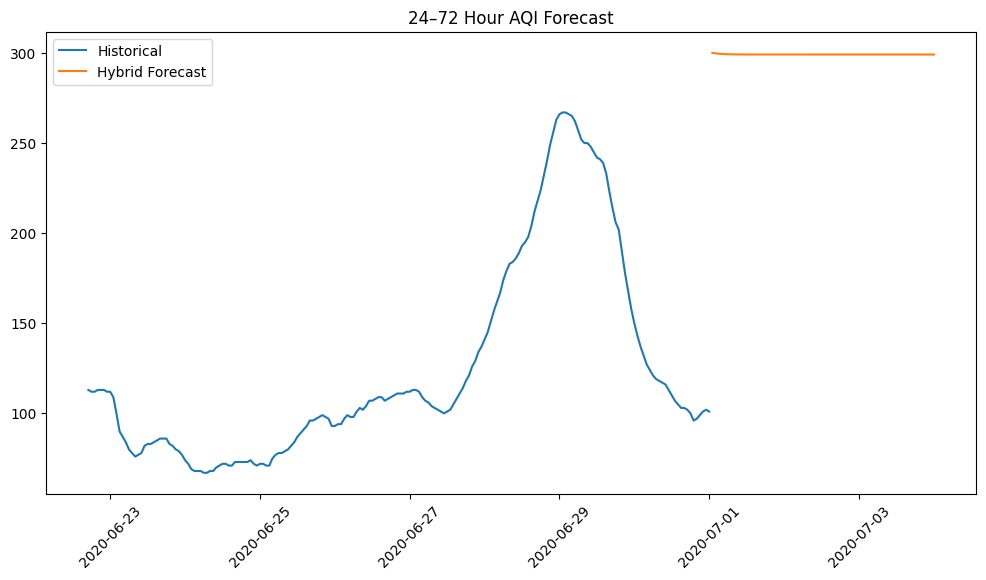

In [66]:
plt.figure(figsize=(12,6))

plt.plot(delhi_hour['AQI'][-200:], label="Historical")

plt.plot(forecast_df["Datetime"],
         forecast_df["Hybrid"],
         label="Hybrid Forecast")

plt.legend()
plt.title("24–72 Hour AQI Forecast")
plt.xticks(rotation=45)
plt.show()


In [67]:
max_aqi = forecast_df["Hybrid"].max()

if max_aqi > 400:
    risk = "Severe+ Emergency"
elif max_aqi > 300:
    risk = "Severe"
elif max_aqi > 200:
    risk = "Very Poor"
elif max_aqi > 100:
    risk = "Moderate"
else:
    risk = "Good"

print("Predicted Risk Level:", risk)


Predicted Risk Level: Severe
